# HYSPLIT Trajectory Modeling

This notebook demonstrates trajectory modeling with the `hysplit` package.

**What you'll learn:**
- Running trajectory models with `hysplit_trajectory()`
- Using the method-chaining API with `create_trajectory_model()`
- Plotting trajectory results

## Setup

Run locally without installing - just add the parent directory to the path:

In [1]:
# Add parent directory to path for local development
import sys
from pathlib import Path

# Get the parent directory (repository root)
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import hysplit
print(f"hysplit version: {hysplit.__version__}")
print(f"Loading from: {repo_root}")

hysplit version: 0.1.0
Loading from: /Users/anzony.quisperojas/Documents/GitHub/python/hysplit


In [2]:
# Create directories for met data and output
met_dir = Path("./met")
out_dir = Path("./out")
met_dir.mkdir(exist_ok=True)
out_dir.mkdir(exist_ok=True)

## 1. Simple Trajectory Run

Run a 24-hour forward trajectory from Ontario, Canada using `hysplit_trajectory()`:

In [3]:
trajectory = hysplit.hysplit_trajectory(
    lat=42.83752,
    lon=-80.30364,
    height=50,
    duration=24,
    days=["2012-03-12"],
    daily_hours=[0, 6, 12, 18],
    direction="forward",
    met_type="reanalysis",
    extended_met=False,
    met_dir=str(met_dir),
    exec_dir=str(out_dir)
)

In [4]:
# View the results
print(f"Trajectory shape: {trajectory.shape}")
print(f"\nColumns: {list(trajectory.columns)}")
trajectory.head(10)

Trajectory shape: (100, 12)

Columns: ['year', 'month', 'day', 'hour', 'hour_along', 'lat', 'lon', 'height', 'pressure', 'traj_dt', 'traj_dt_i', 'run']


,year,month,day,hour,hour_along,lat,lon,height,pressure,traj_dt,traj_dt_i,run
0,2012,3,12,0,0,42.838,-80.304,50.0,984.4,2012-03-12 00:00:00,2012-03-12,1
1,2012,3,12,1,1,42.984,-80.098,49.2,984.3,2012-03-12 01:00:00,2012-03-12,1
2,2012,3,12,2,2,43.126,-79.912,48.3,984.3,2012-03-12 02:00:00,2012-03-12,1
3,2012,3,12,3,3,43.264,-79.750,47.3,984.5,2012-03-12 03:00:00,2012-03-12,1
4,2012,3,12,4,4,43.396,-79.612,46.3,984.7,2012-03-12 04:00:00,2012-03-12,1
5,2012,3,12,5,5,43.522,-79.494,45.3,985.1,2012-03-12 05:00:00,2012-03-12,1
6,2012,3,12,6,6,43.643,-79.395,44.2,985.5,2012-03-12 06:00:00,2012-03-12,1
7,2012,3,12,7,7,43.758,-79.308,43.1,985.9,2012-03-12 07:00:00,2012-03-12,1
8,2012,3,12,8,8,43.866,-79.230,42.0,986.3,2012-03-12 08:00:00,2012-03-12,1
9,2012,3,12,9,9,43.969,-79.164,41.0,986.7,2012-03-12 09:00:00,2012-03-12,1


## 2. Understanding the Output

The trajectory DataFrame contains:

| Column | Description |
|--------|-------------|
| `run` | Index for individual model run |
| `receptor` | Numeric label for the 3D receptor position |
| `hour_along` | Hours from start (positive=forward, negative=backward) |
| `traj_dt` | Date-time of trajectory position |
| `lat`, `lon`, `height` | Position along trajectory |
| `pressure` | Air pressure (hPa) |

In [5]:
# Summary statistics
print("Trajectory Summary:")
print(f"  Number of runs: {trajectory['run'].nunique()}")
print(f"  Lat range: {trajectory['lat'].min():.4f} - {trajectory['lat'].max():.4f}")
print(f"  Lon range: {trajectory['lon'].min():.4f} - {trajectory['lon'].max():.4f}")
print(f"  Height range: {trajectory['height'].min():.1f} - {trajectory['height'].max():.1f} m")

Trajectory Summary:
  Number of runs: 4
  Lat range: 42.8380 - 48.5830
  Lon range: -81.5600 - -78.3610
  Height range: 36.1 - 237.2 m


## 3. Method Chaining API

For more complex workflows, use the object-oriented pipeline approach:

In [6]:
# Create model using method chaining
trajectory_model = (
    hysplit.create_trajectory_model()
    .add_trajectory_params(
        lat=43.45,
        lon=-79.70,
        height=50,
        duration=6,
        days=["2015-07-01"],
        daily_hours=[0, 12],
        direction="backward",
        met_type="reanalysis",
        met_dir=str(met_dir),
        exec_dir=str(out_dir)
    )
    .run()
)

# Extract the trajectory data
trajectory_df = trajectory_model.get_output()
trajectory_df

,year,month,day,hour,hour_along,lat,lon,height,pressure,traj_dt,traj_dt_i,run
0,2015,7,1,0,0,43.450,-79.700,50.0,970.2,2015-07-01 00:00:00,2015-07-01 00:00:00,1
1,2015,6,30,23,-1,43.396,-79.732,44.1,971.0,2015-06-30 23:00:00,2015-07-01 00:00:00,1
2,2015,6,30,22,-2,43.341,-79.751,39.0,971.7,2015-06-30 22:00:00,2015-07-01 00:00:00,1
3,2015,6,30,21,-3,43.285,-79.757,34.5,972.3,2015-06-30 21:00:00,2015-07-01 00:00:00,1
4,2015,6,30,20,-4,43.230,-79.749,30.7,972.8,2015-06-30 20:00:00,2015-07-01 00:00:00,1
5,2015,6,30,19,-5,43.175,-79.727,27.4,973.3,2015-06-30 19:00:00,2015-07-01 00:00:00,1
6,2015,6,30,18,-6,43.120,-79.688,24.5,973.7,2015-06-30 18:00:00,2015-07-01 00:00:00,1
7,2015,7,1,12,0,43.450,-79.700,50.0,970.4,2015-07-01 12:00:00,2015-07-01 12:00:00,2
8,2015,7,1,11,-1,43.476,-79.897,44.6,971.3,2015-07-01 11:00:00,2015-07-01 12:00:00,2
9,2015,7,1,10,-2,43.503,-80.074,40.7,972.0,2015-07-01 10:00:00,2015-07-01 12:00:00,2


## 4. Plotting Trajectories

In [7]:
# Plot trajectory on interactive map (requires folium)
try:
    hysplit.trajectory_plot(trajectory)
except ImportError:
    print("Install folium for interactive maps: pip install folium")

Install folium for interactive maps: pip install folium


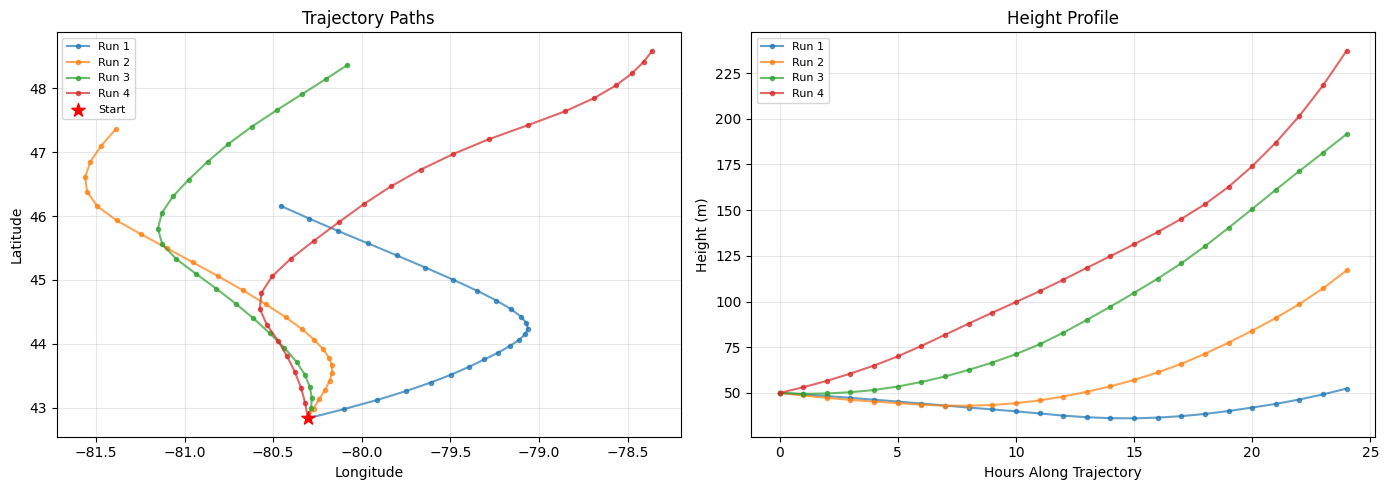

In [8]:
# Static plot with matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Trajectory paths
ax = axes[0]
for run_id in trajectory['run'].unique():
    run_data = trajectory[trajectory['run'] == run_id]
    ax.plot(run_data['lon'], run_data['lat'], 'o-', markersize=3, 
            label=f'Run {run_id}', alpha=0.7)

ax.scatter(trajectory['lon'].iloc[0], trajectory['lat'].iloc[0], 
           c='red', s=100, marker='*', zorder=10, label='Start')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Trajectory Paths')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Height profile
ax = axes[1]
for run_id in trajectory['run'].unique():
    run_data = trajectory[trajectory['run'] == run_id]
    ax.plot(run_data['hour_along'], run_data['height'], 'o-', 
            markersize=3, label=f'Run {run_id}', alpha=0.7)

ax.set_xlabel('Hours Along Trajectory')
ax.set_ylabel('Height (m)')
ax.set_title('Height Profile')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Extended Meteorology

Get additional meteorological variables along the trajectory:

In [9]:
# Run with extended meteorology
trajectory_ext = hysplit.hysplit_trajectory(
    lat=42.83752,
    lon=-80.30364,
    height=50,
    duration=24,
    days=["2012-03-12"],
    daily_hours=[12],
    direction="forward",
    met_type="reanalysis",
    extended_met=True,  # Enable extended meteorology
    met_dir=str(met_dir),
    exec_dir=str(out_dir)
)

# Extended columns include:
# theta, air_temp, rainfall, mixdepth, rh, sp_humidity, h2o_mixrate, terr_msl, sun_flux
print(f"Columns with extended_met=True:")
print(list(trajectory_ext.columns))

Columns with extended_met=True:
['year', 'month', 'day', 'hour', 'hour_along', 'lat', 'lon', 'height', 'pressure', 'theta', 'air_temp', 'rainfall', 'mixdepth', 'rh', 'sp_humidity', 'h2o_mixrate', 'traj_dt', 'traj_dt_i', 'run']
